In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [14]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [26]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0
(7043, 21)


In [27]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# converted 0 and 1 values of senior citizens to yes/no to make it easier to understand

In [31]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)
    

In [32]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


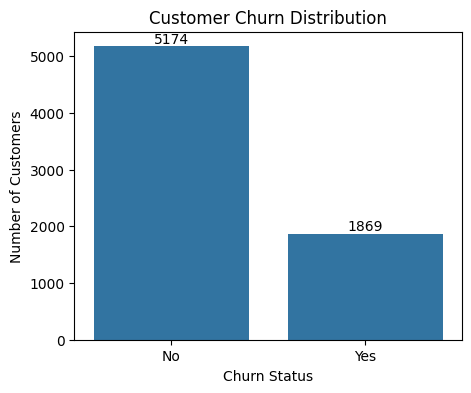

In [39]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Churn', data=df)
ax.bar_label(ax.containers[0])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()


### Insight

The visualization shows that the majority of customers have **not churned**, while a smaller portion of customers have discontinued the service. 
This indicates that customer retention is relatively strong. However, the presence of a noticeable churn segment suggests that the company should further analyze the factors contributing to customer churn.

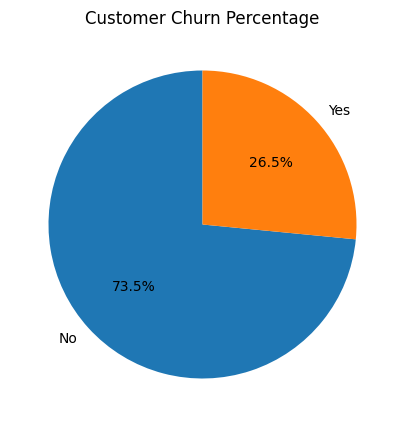

In [41]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Churn Percentage")
plt.show()

### Insight
From the given pie chart we can conclude that 26.54% of our customers have churned out
Now let's explore the reasons behind it

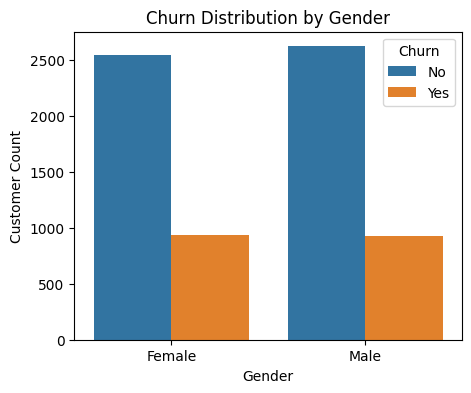

In [44]:
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data=df, hue='Churn')
plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

### Insight
From the visualization, we observe that churn distribution is almost similar for both male and female customers. 
This indicates that gender does not play a significant role in customer churn.

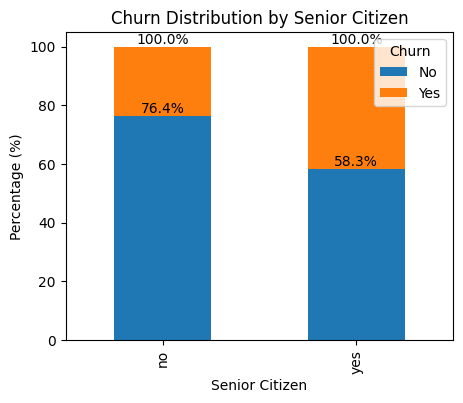

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Create cross tabulation
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert counts to percentage
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(5,4))
plt.legend(title="Churn", loc='upper right')

plt.title("Churn Distribution by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")

# Add percentage labels
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%')

plt.show()

### Insight

The visualization indicates that **senior citizens have a higher churn rate** compared to non-senior customers. This suggests that older customers may be more likely to discontinue telecom services.

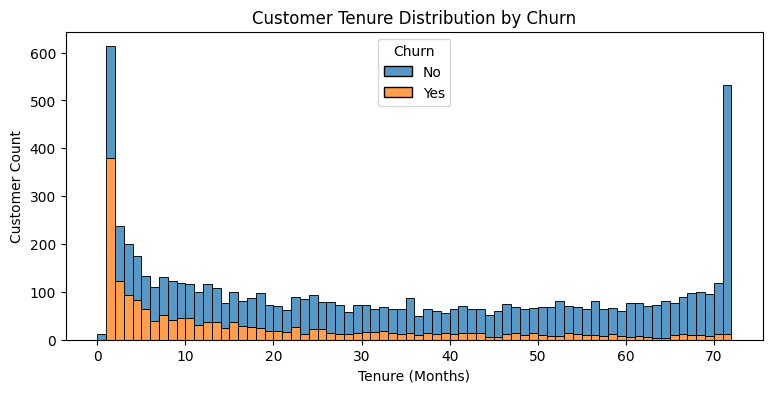

In [52]:
plt.figure(figsize=(9,4))
sns.histplot(x='tenure', data=df, bins=72, hue='Churn', multiple='stack')
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")
plt.show()

### Insight

The histogram shows that customers with lower tenure have a higher churn rate. 
This indicates that newer customers are more likely to discontinue the service, while long-term customers tend to remain with the company.

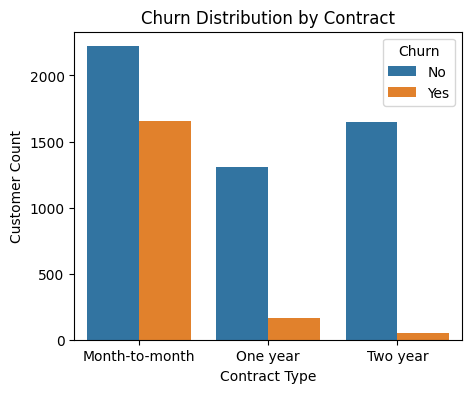

In [54]:
plt.figure(figsize=(5,4))
sns.countplot(x='Contract', data=df, hue='Churn')
plt.title("Churn Distribution by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()


### Insight

The visualization shows that customers with **month-to-month contracts have a significantly higher churn rate** 
compared to those with one-year or two-year contracts.
This suggests that longer contract commitments help reduce customer churn.

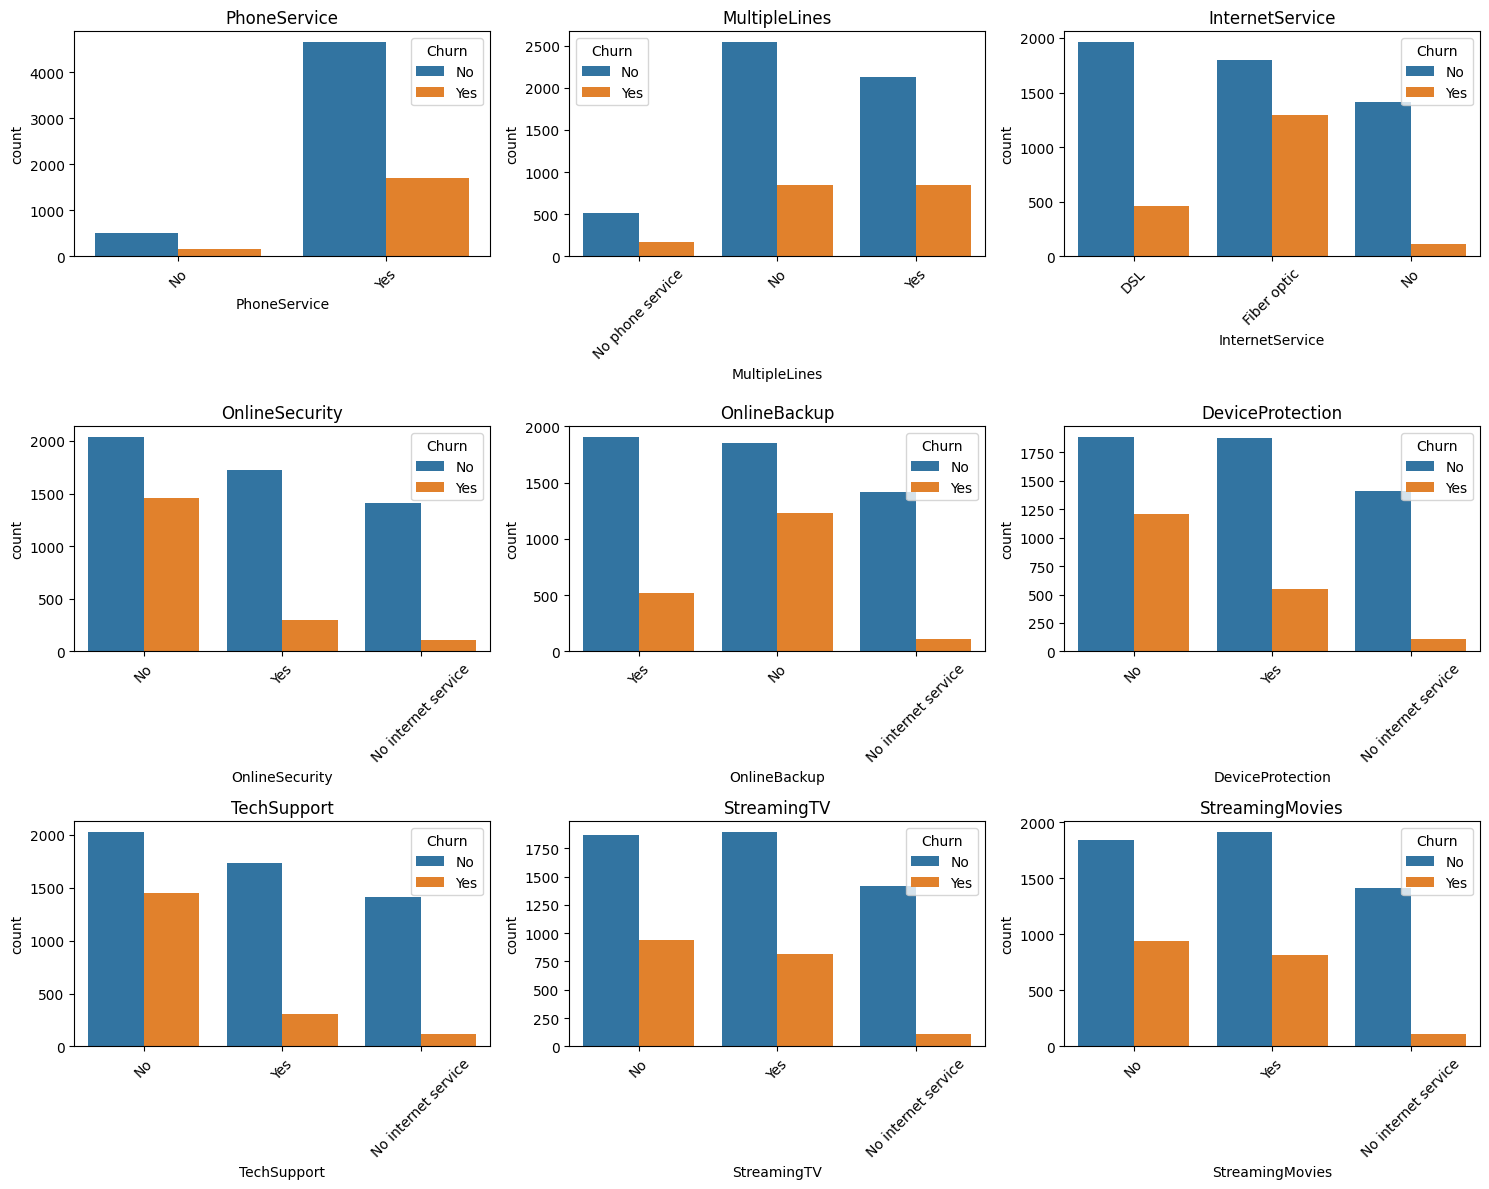

In [57]:
cols = ['PhoneService','MultipleLines','InternetService',
        'OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies']

plt.figure(figsize=(15,12))

for i, col in enumerate(cols):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, data=df, hue='Churn')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

From the visualizations, customers who do not subscribe to additional services such as **OnlineSecurity, TechSupport, and DeviceProtection** show a noticeably higher churn rate compared to those who have these services. 

Similarly, customers with **fiber optic internet service** appear to churn more frequently than those using DSL or having no internet service. 

Overall, the analysis suggests that customers with **fewer value-added services are more likely to churn**, while those using multiple services tend to remain with the company.

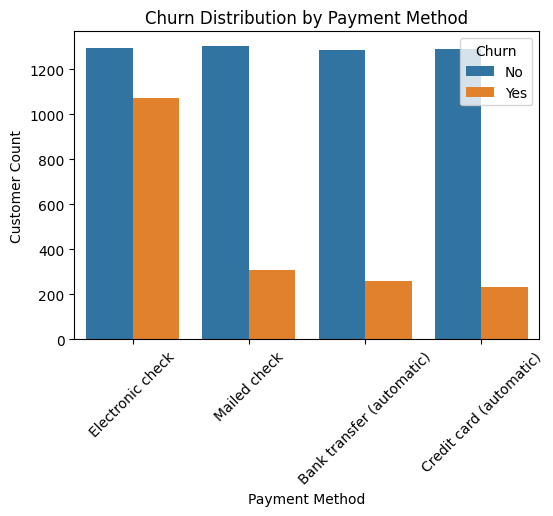

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', data=df, hue='Churn')
plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.show()

### Insight

The visualization shows that customers using **electronic check as their payment method have the highest churn rate**. 
In contrast, customers using **automatic payment methods such as bank transfer or credit card tend to have lower churn rates**, 
suggesting that automated payment options may help improve customer retention.